## Chargement fichier et verification

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier
df = pd.read_csv('dvf_bpe_ecoles.csv')

# Vérification rapide
print(f"Dimensions du dataset : {df.shape}")
print("\n--- Aperçu des nouvelles colonnes de distance ---")
print(df[['dist_primaire', 'dist_college', 'dist_lycee', 'dist_superieur', 'dist_prive']].head())

# Vérification des types
print("\n--- Types des colonnes ---")
print(df.dtypes.value_counts())

Dimensions du dataset : (4640555, 20)

--- Aperçu des nouvelles colonnes de distance ---
   dist_primaire  dist_college  dist_lycee  dist_superieur  dist_prive
0       2.423635      2.502423    4.417832       15.692617    2.423635
1       0.699041      0.760541   15.883451       22.204618   11.085321
2       0.661846      1.038082    0.601862        8.271484    0.601862
3       0.740946      0.944305    7.901046       13.177792    4.122239
4       0.185566      2.277925    2.777157       11.643646    1.601661

--- Types des colonnes ---
float64    11
int64       9
Name: count, dtype: int64


In [2]:
# Afficher les statistiques de toutes les colonnes pour détecter des anomalies
stats = df.describe().T
stats['unique_values'] = df.nunique()
print(stats[['min', 'max', 'mean', 'unique_values']])

# Lister toutes les colonnes pour faire le tri
print("\nListe des colonnes actuelles :")
print(df.columns.tolist())

                                   min           max           mean  \
surface_reelle_bati          10.000000  5.000000e+02      96.246289   
nombre_pieces_principales     1.000000  5.600000e+01       4.110965   
surface_terrain               0.000000  1.000000e+04     457.009884   
valeur_fonciere            3000.000000  1.399508e+07  244781.095156   
annee                      2020.000000  2.025000e+03    2022.234156   
mois                          1.000000  1.200000e+01       6.776911   
code_departement              1.000000  9.740000e+02      62.396753   
longitude                   -63.144340  5.582923e+01       2.483438   
latitude                    -21.386149  5.108207e+01      46.159549   
is_maison                     0.000000  1.000000e+00       0.543750   
is_neuf                       0.000000  1.000000e+00       0.022509   
anciennete_mois               6.000000  6.500000e+01      38.413214   
commune_prix_m2             115.384615  1.477273e+04    2938.353386   
commun

In [3]:
# 1. On définit la cible
target = 'valeur_fonciere'

# 2. On choisit les variables à exclure
# On enlève 'commune_prix_m2' pour éviter que le modèle ne "triche"
cols_to_drop = [target, 'commune_prix_m2', 'commune_volume']

X = df.drop(columns=cols_to_drop)
y = df[target]

# 3. Vérification des types pour XGBoost
# Tout est déjà en float/int d'après ton audit, donc c'est parfait.

## Split et entrainement

In [4]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Configuration XGBoost optimisée pour 4.6M de lignes
model_xgb = xgb.XGBRegressor(
    n_estimators=500,       # On peut monter un peu plus
    learning_rate=0.05,     # Un pas plus lent pour plus de précision
    max_depth=8,            # Un peu plus profond pour capturer les interactions géo
    tree_method='hist',     # Vitesse maximale
    device='cuda',          # Si tu as un GPU NVIDIA, sinon retire cette ligne
    n_jobs=-1,              # Utilise tous les cœurs du processeur
    random_state=42
)

print("Entraînement en cours (cela peut prendre quelques minutes)...")
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50 # Affiche le score tous les 50 arbres
)

print("\nEntraînement terminé !")

Entraînement en cours (cela peut prendre quelques minutes)...


c:\Users\carine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:16:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\carine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:16:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-rmse:242290.81152
[50]	validation_0-rmse:150418.52759
[100]	validation_0-rmse:142044.25220
[150]	validation_0-rmse:138317.61451
[200]	validation_0-rmse:135928.13773
[250]	validation_0-rmse:133949.00087
[300]	validation_0-rmse:132417.00538
[350]	validation_0-rmse:131480.99173
[400]	validation_0-rmse:130602.92646
[450]	validation_0-rmse:129884.70724
[499]	validation_0-rmse:129348.48707

Entraînement terminé !


<Figure size 1000x800 with 0 Axes>

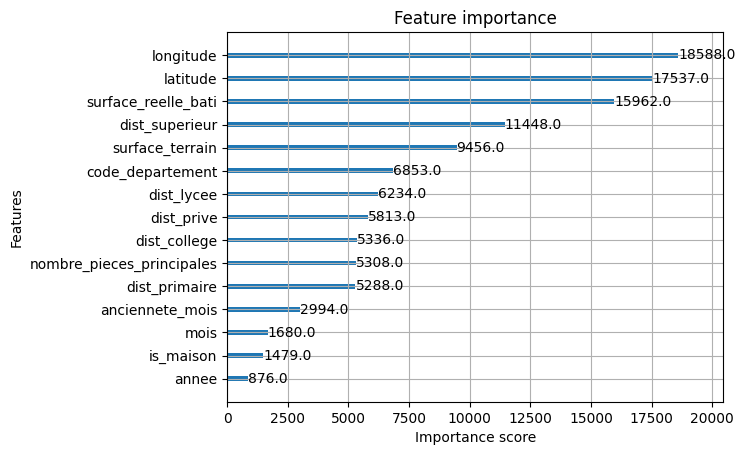

In [5]:
# Affichage de l'importance des variables
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, max_num_features=15, importance_type='weight')
plt.show()

In [6]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Prédiction sur le jeu de test
y_pred = model_xgb.predict(X_test)

# 2. Calcul des métriques
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"--- Performance du Modèle ---")
print(f"Score R² : {r2:.4f}")
print(f"Erreur Moyenne (MAE) : {mae:.2f} €")

--- Performance du Modèle ---
Score R² : 0.7300
Erreur Moyenne (MAE) : 63521.50 €
